In [56]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [58]:
df=pd.read_csv('data\stud.csv')

In [59]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [60]:
x=df.drop(columns=['math_score'],axis=1)

In [61]:
x.shape

(1000, 7)

In [62]:
y=df['math_score']

In [63]:
print("Categories in 'gender' variable: ",end="")
print(df['gender'].unique())
print("Categories in 'race_ethnicity' variable: ",end="")
print(df['race_ethnicity'].unique())
print("Categories in 'parental_level_of_education' variable: ",end="")
print(df['parental_level_of_education'].unique())
print("Categories in 'lunch' variable: ",end="")
print(df['lunch'].unique())
print("Categories in 'test_preparation_course' variable: ",end="")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable: ['female' 'male']
Categories in 'race_ethnicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable: ['none' 'completed']


In [64]:
num_features=x.select_dtypes(exclude='object').columns
cat_features=x.select_dtypes(include='object').columns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer=StandardScaler()
cat_transformer=OneHotEncoder()
preprocesser=ColumnTransformer(
    [
        ("onehotencoder",cat_transformer,cat_features),
        ("standedscaler",numeric_transformer,num_features)
    ]
)

In [65]:
preprocesser

ColumnTransformer(transformers=[('onehotencoder', OneHotEncoder(),
                                 Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')),
                                ('standedscaler', StandardScaler(),
                                 Index(['reading_score', 'writing_score'], dtype='object'))])

In [66]:
x=preprocesser.fit_transform(x)

In [67]:
x.shape

(1000, 19)

In [68]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(x_train.shape, y_train.shape)

(800, 19) (800,)


In [69]:
def evaluate_metrics(true,predict):
    mae=mean_absolute_error(true,predict)
    mse=mean_squared_error(true,predict)
    rmse=np.sqrt(mean_squared_error(true,predict))
    r2_square=r2_score(true,predict)
    return mae,rmse,r2_square

In [70]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
    "AdaBoostRegressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_rmse, model_train_r2_square = evaluate_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2_square = evaluate_metrics(y_test, y_test_pred)

    print(name)

    model_list.append(name)

    print("Model performance for Training set")
    print("RMSE: {:.4f}".format(model_train_rmse))
    print("MAE: {:.4f}".format(model_train_mae))
    print("R2 Score: {:.4f}".format(model_train_r2_square))

    print('----------------------------------')

    print("Model performance for Testing set")
    print("RMSE: {:.4f}".format(model_test_rmse))
    print("MAE: {:.4f}".format(model_test_mae))
    print("R2 Score: {:.4f}".format(model_test_r2_square))

    r2_list.append(model_test_r2_square)

    print("=" * 35)
    print("\n")

LinearRegression
Model performance for Training set
RMSE: 5.3272
MAE: 4.2784
R2 Score: 0.8741
----------------------------------
Model performance for Testing set
RMSE: 5.4108
MAE: 4.2279
R2 Score: 0.8797


Lasso
Model performance for Training set
RMSE: 6.5938
MAE: 5.2063
R2 Score: 0.8071
----------------------------------
Model performance for Testing set
RMSE: 6.5197
MAE: 5.1579
R2 Score: 0.8253


Ridge
Model performance for Training set
RMSE: 5.3233
MAE: 4.2650
R2 Score: 0.8743
----------------------------------
Model performance for Testing set
RMSE: 5.3904
MAE: 4.2111
R2 Score: 0.8806


KNeighborsRegressor
Model performance for Training set
RMSE: 5.7122
MAE: 4.5187
R2 Score: 0.8553
----------------------------------
Model performance for Testing set
RMSE: 7.2516
MAE: 5.6160
R2 Score: 0.7839


DecisionTreeRegressor
Model performance for Training set
RMSE: 0.2795
MAE: 0.0187
R2 Score: 0.9997
----------------------------------
Model performance for Testing set
RMSE: 8.0265
MAE: 6.295

In [73]:
pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['model name', 'r2 score']
).sort_values(by=['r2 score'], ascending=False)

,model name,r2 score
2,Ridge,0.880593
0,LinearRegression,0.879689
5,RandomForestRegressor,0.856058
7,CatBoostRegressor,0.851632
8,AdaBoostRegressor,0.843654
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,KNeighborsRegressor,0.783898
4,DecisionTreeRegressor,0.735245


In [74]:
lg_model=LinearRegression(fit_intercept=True)
lg_model=lg_model.fit(x_train,y_train)
y_pred=lg_model.predict(x_test)
score=r2_score(y_test,y_pred)*100
print(f"accuracy of model is:",{score})

accuracy of model is: {87.96891037899151}


Text(0, 0.5, 'predicted')

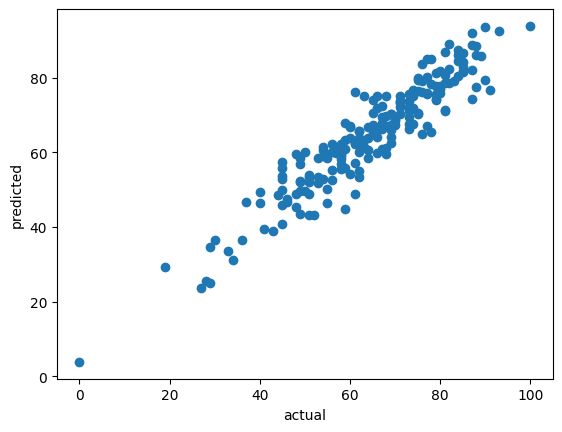

In [75]:
plt.scatter(y_test,y_pred)
plt.xlabel('actual')
plt.ylabel('predicted')

<Axes: xlabel='math_score'>

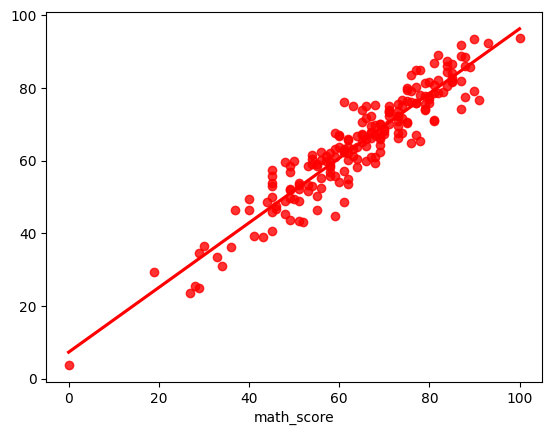

In [76]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [77]:
pred_df=pd.DataFrame({'actual_value':y_test,'predicted_value':y_pred,'difference':y_test-y_pred})
pred_df

,actual_value,predicted_value,difference
521,91,76.734375,14.265625
737,53,58.593750,-5.593750
740,80,76.843750,3.156250
660,74,76.750000,-2.750000
411,84,87.500000,-3.500000
...,...,...,...
408,52,43.156250,8.843750
332,62,62.125000,-0.125000
208,74,67.578125,6.421875
613,65,67.343750,-2.343750
